# Лабораторна робота 1 — Дослідження даних з NumPy, Pandas та scikit-learn

**Набір даних:** `kc_house_data.csv`  
**Дозволені бібліотеки:** NumPy, Pandas, Matplotlib, scikit-learn (усі модулі)

## Налаштування — встановлення залежностей та імпорт

Запустіть комірку нижче один раз, щоб переконатись, що всі необхідні пакети встановлені.

In [1]:
# Встановлення залежностей (можна запускати повторно)
import sys
!{sys.executable} -m pip install numpy pandas matplotlib scikit-learn --quiet

In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.linear_model import LinearRegression
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error
from pathlib import Path

%matplotlib inline
plt.rcParams['figure.figsize'] = (10, 5)


---
## Завдання 1 — Розминка з NumPy

**а)** Створіть масив NumPy з 10 000 значень, що підпорядковані нормальному розподілу N(0, 1). Обчисліть середнє, стандартне відхилення, мінімум і максимум за допомогою функцій NumPy — **без Python-циклів**.

**б)** Підрахуйте, скільки значень виходять за межі ±2 стандартних відхилення, використовуючи логічну індексацію. Яка це відсоткова частка? Порівняйте з теоретичним значенням ≈4,55 %.

In [3]:
# Завдання 1а — створюємо масив і обчислюємо статистику без Python-циклів
rng = np.random.default_rng(42)
normal_values = rng.normal(loc=0, scale=1, size=10_000)

mean_value = np.mean(normal_values)
std_value = np.std(normal_values)
min_value = np.min(normal_values)
max_value = np.max(normal_values)

stats_task1 = pd.Series({
    'Середнє': mean_value,
    'Стандартне відхилення': std_value,
    'Мінімум': min_value,
    'Максимум': max_value,
})

stats_task1.round(4)


Середнє                 -0.0102
Стандартне відхилення    1.0063
Мінімум                 -4.3891
Максимум                 4.0258
dtype: float64

In [4]:
# Завдання 1б — підрахуйте викиди за допомогою логічної індексації
lower_bound = mean_value - 2 * std_value
upper_bound = mean_value + 2 * std_value

outside_2std_mask = (normal_values < lower_bound) | (normal_values > upper_bound)
outside_2std_count = np.sum(outside_2std_mask)
outside_2std_percent = outside_2std_count / normal_values.size * 100

task1_outliers = pd.DataFrame({
    'Показник': [
        'Нижня межа',
        'Верхня межа',
        'Кількість значень за межами ±2σ',
        'Частка, %',
        'Теоретичне значення, %',
    ],
    'Значення': [
        lower_bound,
        upper_bound,
        outside_2std_count,
        outside_2std_percent,
        4.55,
    ],
})

task1_outliers


,Показник,Значення
0,Нижня межа,-2.022821
1,Верхня межа,2.002322
2,Кількість значень за межами ±2σ,446.000000
3,"Частка, %",4.460000
4,"Теоретичне значення, %",4.550000


**Відповідь (б):** За межі ±2 стандартних відхилення потрапило **446 значень**, тобто приблизно **4,46 %** вибірки. Це дуже близько до теоретичного значення **≈4,55 %** для нормального розподілу, а невелика різниця пояснюється випадковістю згенерованої вибірки.


---
## Завдання 2 — Завантаження та огляд набору даних

Завантажте `kc_house_data.csv` у Pandas DataFrame та дайте відповідь на питання нижче, написавши код:

1. Скільки рядків і стовпців у наборі даних?
2. Які мінімум, максимум, середнє та медіана цін на будинки?
3. Скільки унікальних поштових індексів є у наборі даних? Який поштовий індекс має найбільше оголошень?

In [5]:
# Завантаження набору даних
data_path = Path('kc_house_data.csv')
if not data_path.exists():
    data_path = Path('/mnt/data/kc_house_data.csv')

sales = pd.read_csv(data_path)
sales.head()


,id,date,price,bedrooms,bathrooms,sqft_living,sqft_lot,floors,waterfront,view,...,grade,sqft_above,sqft_basement,yr_built,yr_renovated,zipcode,lat,long,sqft_living15,sqft_lot15
0,7129300520,20141013T000000,221900.0,3,1.00,1180,5650,1.0,0,0,...,7,1180,0,1955,0,98178,47.5112,-122.257,1340,5650
1,6414100192,20141209T000000,538000.0,3,2.25,2570,7242,2.0,0,0,...,7,2170,400,1951,1991,98125,47.7210,-122.319,1690,7639
2,5631500400,20150225T000000,180000.0,2,1.00,770,10000,1.0,0,0,...,6,770,0,1933,0,98028,47.7379,-122.233,2720,8062
3,2487200875,20141209T000000,604000.0,4,3.00,1960,5000,1.0,0,0,...,7,1050,910,1965,0,98136,47.5208,-122.393,1360,5000
4,1954400510,20150218T000000,510000.0,3,2.00,1680,8080,1.0,0,0,...,8,1680,0,1987,0,98074,47.6168,-122.045,1800,7503


In [6]:
# 2-і) Скільки рядків і стовпців?
rows_count, columns_count = sales.shape

print(f'Кількість рядків: {rows_count}')
print(f'Кількість стовпців: {columns_count}')


Кількість рядків: 21613
Кількість стовпців: 21


In [7]:
# 2-іі) Мінімум, максимум, середнє та медіана ціни
price_statistics = sales['price'].agg(['min', 'max', 'mean', 'median'])
price_statistics.index = ['Мінімум', 'Максимум', 'Середнє', 'Медіана']

price_statistics.round(2)


Мінімум       75000.00
Максимум    7700000.00
Середнє      540088.14
Медіана      450000.00
Name: price, dtype: float64

In [8]:
# 2-ііі) Кількість унікальних поштових індексів; індекс з найбільшою кількістю оголошень
unique_zipcodes_count = sales['zipcode'].nunique()
zipcode_counts = sales['zipcode'].value_counts()
most_common_zipcode = zipcode_counts.idxmax()
most_common_zipcode_ads = zipcode_counts.max()

print(f'Кількість унікальних поштових індексів: {unique_zipcodes_count}')
print(f'Поштовий індекс з найбільшою кількістю оголошень: {most_common_zipcode}')
print(f'Кількість оголошень для цього індексу: {most_common_zipcode_ads}')


Кількість унікальних поштових індексів: 70
Поштовий індекс з найбільшою кількістю оголошень: 98103
Кількість оголошень для цього індексу: 602


---
## Завдання 3 — Візуалізація даних

Створіть **два графіки поруч**:

- **Лівий:** гістограма `price` (50 інтервалів, логарифмічна шкала по осі X).
- **Правий:** діаграма розсіювання `sqft_living` vs `price`, де кольором точок позначено `bedrooms`. Додайте підписи осей і colorbar.

Одним реченням для кожного графіка опишіть, що ви спостерігаєте.

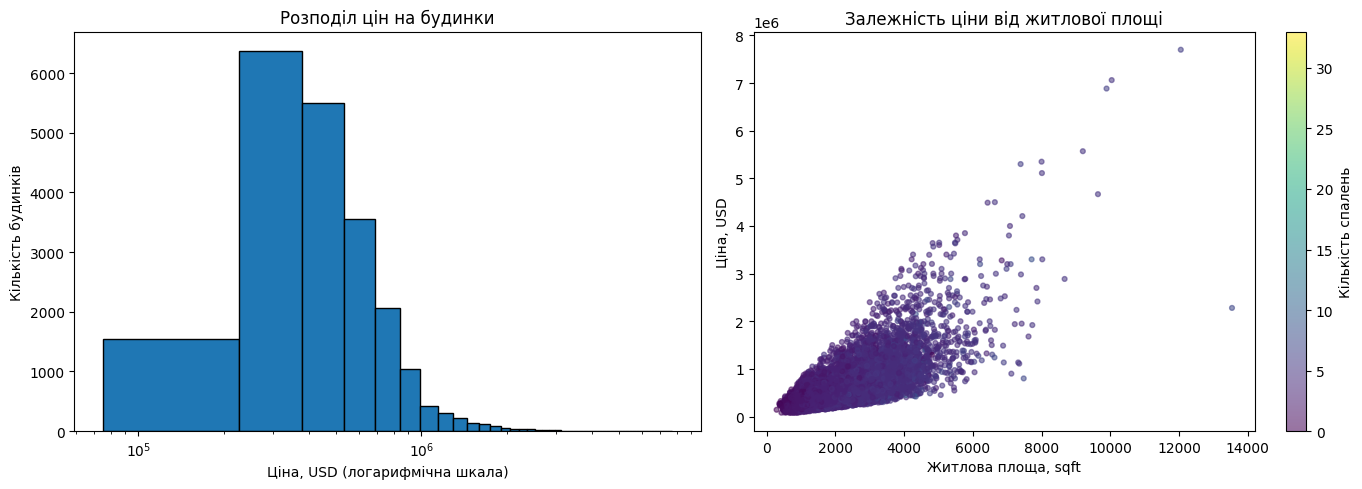

In [9]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Завдання 3 — лівий графік: гістограма ціни
axes[0].hist(sales['price'], bins=50, edgecolor='black')
axes[0].set_xscale('log')
axes[0].set_title('Розподіл цін на будинки')
axes[0].set_xlabel('Ціна, USD (логарифмічна шкала)')
axes[0].set_ylabel('Кількість будинків')

# Завдання 3 — правий графік: діаграма розсіювання sqft_living vs price
scatter = axes[1].scatter(
    sales['sqft_living'],
    sales['price'],
    c=sales['bedrooms'],
    cmap='viridis',
    alpha=0.55,
    s=12,
)
axes[1].set_title('Залежність ціни від житлової площі')
axes[1].set_xlabel('Житлова площа, sqft')
axes[1].set_ylabel('Ціна, USD')
colorbar = fig.colorbar(scatter, ax=axes[1])
colorbar.set_label('Кількість спалень')

plt.tight_layout()
plt.show()


**Спостереження (лівий графік):** Розподіл цін правосторонньо асиметричний: більшість будинків має відносно нижчу або середню ціну, а дуже дорогі будинки трапляються значно рідше.

**Спостереження (правий графік):** Загалом зі збільшенням житлової площі `sqft_living` ціна будинку зростає, але точки мають великий розкид, тому сама площа не пояснює ціну повністю.


---
## Завдання 4 — Навчання та оцінка регресійної моделі

Розбийте дані 80/20 (`random_state=42`). Навчіть `LinearRegression` з scikit-learn для передбачення `price` за єдиною ознакою `sqft_living`.

1. Вкажіть вільний член (intercept) та коефіцієнт для `sqft_living`.
2. Обчисліть MSE і RMSE на тестовій вибірці.
3. Яка передбачувана ціна будинку площею 2 500 кв. футів?

In [10]:
# Поділ на навчальну та тестову вибірки
train_data, test_data = train_test_split(sales, test_size=0.2, random_state=42)


In [11]:
# Завдання 4 — навчіть модель, вкажіть ваги, обчисліть MSE/RMSE, передбачте ціну для 2500 кв. фут.
model_1_features = ['sqft_living']
X_train_1 = train_data[model_1_features]
y_train = train_data['price']
X_test_1 = test_data[model_1_features]
y_test = test_data['price']

model_1 = LinearRegression()
model_1.fit(X_train_1, y_train)

model_1_predictions = model_1.predict(X_test_1)
model_1_mse = mean_squared_error(y_test, model_1_predictions)
model_1_rmse = np.sqrt(model_1_mse)

house_2500 = pd.DataFrame({'sqft_living': [2500]})
predicted_price_2500 = model_1.predict(house_2500)[0]

model_1_results = pd.DataFrame({
    'Показник': [
        'Intercept / вільний член',
        'Коефіцієнт для sqft_living',
        'MSE на тестовій вибірці',
        'RMSE на тестовій вибірці',
        'Прогноз ціни для 2500 sqft',
    ],
    'Значення': [
        model_1.intercept_,
        model_1.coef_[0],
        model_1_mse,
        model_1_rmse,
        predicted_price_2500,
    ],
})

model_1_results


,Показник,Значення
0,Intercept / вільний член,-4.199919e+04
1,Коефіцієнт для sqft_living,2.795548e+02
2,MSE на тестовій вибірці,7.648498e+10
3,RMSE на тестовій вибірці,2.765592e+05
4,Прогноз ціни для 2500 sqft,6.568878e+05


---
## Завдання 5 — Порівняння двох моделей

Навчіть другу `LinearRegression` з ознаками: `sqft_living`, `bedrooms`, `bathrooms`, `yr_built`. Порівняйте RMSE на тестовій вибірці між Моделлю 1 та Моделлю 2. Яке значення нижче? Коротко поясніть чому.

In [12]:
# Завдання 5 — модель з чотирма ознаками та порівняння RMSE
model_2_features = ['sqft_living', 'bedrooms', 'bathrooms', 'yr_built']
X_train_2 = train_data[model_2_features]
X_test_2 = test_data[model_2_features]

model_2 = LinearRegression()
model_2.fit(X_train_2, y_train)

model_2_predictions = model_2.predict(X_test_2)
model_2_mse = mean_squared_error(y_test, model_2_predictions)
model_2_rmse = np.sqrt(model_2_mse)

coefficients_model_2 = pd.Series(model_2.coef_, index=model_2_features, name='Коефіцієнт')
comparison_rmse = pd.DataFrame({
    'Модель': [
        'Модель 1: sqft_living',
        'Модель 2: sqft_living + bedrooms + bathrooms + yr_built',
    ],
    'RMSE': [model_1_rmse, model_2_rmse],
})

print(f'Intercept моделі 2: {model_2.intercept_:.2f}')
display(coefficients_model_2.to_frame().round(2))
display(comparison_rmse.round(2))


Intercept моделі 2: 6112448.72


,Коефіцієнт
sqft_living,296.13
bedrooms,-68991.68
bathrooms,88164.06
yr_built,-3116.42


,Модель,RMSE
0,Модель 1: sqft_living,276559.17
1,Модель 2: sqft_living + bedrooms + bathrooms +...,262985.98


**Відповідь:** Нижче значення RMSE має **Модель 2**: приблизно **262 985,98** проти **276 559,17** у Моделі 1. Це логічно, тому що друга модель використовує більше ознак (`sqft_living`, `bedrooms`, `bathrooms`, `yr_built`) і тому враховує не лише площу, а й частину інших характеристик будинку, які також впливають на ціну.


---
## ✨ Бонус — Аналіз залишків

Для вашої кращої моделі обчисліть вектор залишків (predicted − actual). Побудуйте гістограму. Чи виглядають залишки нормально розподіленими та центрованими навколо нуля? Що означав би систематичний ненульовий середній залишок?

Краща модель за RMSE: Модель 2
Середній залишок: -1611.51
Медіана залишків: 18429.44
Стандартне відхилення залишків: 263011.46


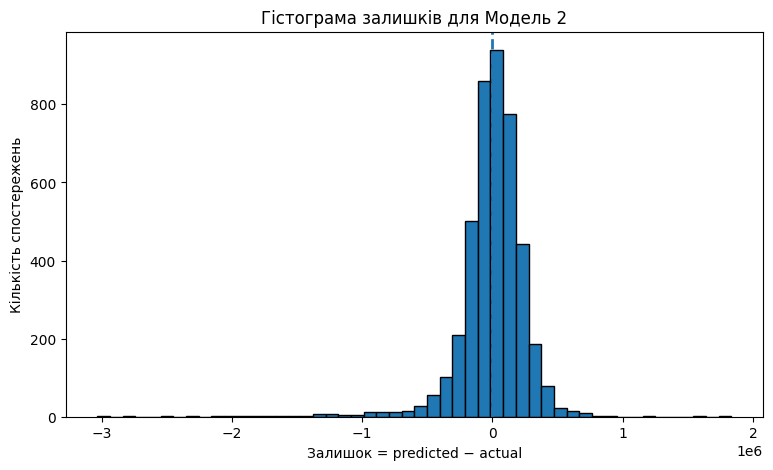

In [13]:
# Бонус — аналіз залишків
best_model_name = 'Модель 2' if model_2_rmse < model_1_rmse else 'Модель 1'
best_predictions = model_2_predictions if model_2_rmse < model_1_rmse else model_1_predictions

residuals = best_predictions - y_test

print(f'Краща модель за RMSE: {best_model_name}')
print(f'Середній залишок: {residuals.mean():.2f}')
print(f'Медіана залишків: {np.median(residuals):.2f}')
print(f'Стандартне відхилення залишків: {residuals.std():.2f}')

plt.figure(figsize=(9, 5))
plt.hist(residuals, bins=50, edgecolor='black')
plt.title(f'Гістограма залишків для {best_model_name}')
plt.xlabel('Залишок = predicted − actual')
plt.ylabel('Кількість спостережень')
plt.axvline(0, linestyle='--', linewidth=2)
plt.show()


**Спостереження:** Залишки кращої моделі в середньому близькі до нуля, але їхній розподіл не виглядає ідеально нормальним: є асиметрія та помітні великі відхилення для дорогих або нетипових будинків. Систематичний ненульовий середній залишок означав би, що модель у середньому зміщена: якщо середній залишок додатний, вона переоцінює ціни, а якщо від’ємний — недооцінює.
